# 04 — Using several measurement points together

Several raw temperature-boundary points are combined. We compare multivariate linear regression,
linear regression on `log1p(x)`, and a multi-point power law. Greedy point selection uses only
training and validation; test and `test_extra` remain final evaluations.

## Software, models, and configurable parameters

This notebook extends Notebook 03 to several raw points. `GAS` selects the target and
`N_FEATURES` selects between 2 and 13 temperatures. A greedy search adds at most one point per
temperature and uses only power-law validation RMSE. The same selected matrix is then supplied
to raw linear, log1p linear, and multi-point power-law models. More features can increase
flexibility, collinearity, and extrapolation risk, so test sets remain untouched during selection.

In [1]:
# Hydrogen is the robust positive example in this dataset.
# Use, for example, acetone for the more difficult VOC case.
GAS = "hydrogen"
N_FEATURES = 13

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))
from dataset_pipeline import *

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unknown gas: {GAS}")
if not 2 <= N_FEATURES <= len({p.temperature_c for p in temperature_boundary_points()}):
    raise ValueError("N_FEATURES must be between 2 and 13")
plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

## 1. Three models for the same feature matrix

In [3]:
def matrix(split, indices):
    return splits[split]["X"][:, 0, indices].astype(float)


def fit_affine(X, y):
    design = np.column_stack([X, np.ones(len(X))])
    coefficients = np.linalg.lstsq(design, y, rcond=None)[0]
    return coefficients[:-1], float(coefficients[-1])


def make_linear_raw(X_train, y_train):
    weights, intercept = fit_affine(X_train, y_train)
    return {
        "name": "Linear: stored values",
        "predict": lambda X: np.asarray(X) @ weights + intercept,
        "parameters": {"weights": weights, "intercept": intercept},
    }


def make_linear_log1p(X_train, y_train):
    weights, intercept = fit_affine(np.log1p(X_train), y_train)
    return {
        "name": "Linear: log1p(x)",
        "predict": lambda X: np.log1p(np.asarray(X)) @ weights + intercept,
        "parameters": {"weights": weights, "intercept": intercept},
    }


def make_power_law(X_train, y_train):
    if np.any(X_train <= 0) or np.any(y_train <= 0):
        raise ValueError("Power law requires positive values only")
    scales = np.median(X_train, axis=0)
    log_inputs = np.log(X_train / scales)
    exponents, log_amplitude = fit_affine(log_inputs, np.log(y_train))
    amplitude = float(np.exp(log_amplitude))

    def predict(X):
        log_prediction = (
            log_amplitude
            + np.log(np.asarray(X) / scales) @ exponents
        )
        return np.exp(np.clip(log_prediction, -50, 50))

    return {
        "name": "Multi-point power law",
        "predict": predict,
        "parameters": {
            "A": amplitude, "n": exponents, "scales": scales,
        },
    }


def metrics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "R2": 1.0 - float(np.sum(residual ** 2)) / denominator,
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": float(np.mean(np.abs(residual))),
    }

The multi-point power law is $C=A\prod_j(x_j/s_j)^{n_j}$. Each point has its own exponent;
the scales are training medians used only for numerical stability.

## 2. Greedy selection by power-law validation error

In [4]:
y_train = splits["train"]["targets"][GAS].astype(float)
y_val = splits["val"]["targets"][GAS].astype(float)
candidates = list(temperature_boundary_points())
selected_points = []
selection_history = []

for step in range(N_FEATURES):
    used_temperatures = {point.temperature_c for point in selected_points}
    trials = []
    for point in candidates:
        if point in selected_points or point.temperature_c in used_temperatures:
            continue
        trial_points = [*selected_points, point]
        indices = [item.index for item in trial_points]
        model = make_power_law(
            matrix("train", indices), y_train
        )
        prediction = model["predict"](matrix("val", indices))
        trials.append((metrics(y_val, prediction)["RMSE"], point))
    best_rmse, best_point = min(trials, key=lambda item: item[0])
    selected_points.append(best_point)
    selection_history.append(best_rmse)
    print(
        f"Schritt {step + 1}: {best_point.point_id}, "
        f"Power-Law Val-RMSE={best_rmse:.4f}"
    )

selected_indices = [point.index for point in selected_points]

Schritt 1: t350_low_step10_end_i1319, Power-Law Val-RMSE=396.6234
Schritt 2: t400_high_step05_end_i0649, Power-Law Val-RMSE=219.7593
Schritt 3: t250_low_step06_end_i0839, Power-Law Val-RMSE=187.4272
Schritt 4: t100_low_step00_end_i0119, Power-Law Val-RMSE=169.0441
Schritt 5: t225_low_step05_end_i0719, Power-Law Val-RMSE=163.9462
Schritt 6: t325_low_step09_end_i1199, Power-Law Val-RMSE=156.7764
Schritt 7: t200_low_step04_end_i0599, Power-Law Val-RMSE=155.0455
Schritt 8: t275_low_step07_start_i0890, Power-Law Val-RMSE=154.0435
Schritt 9: t375_low_step11_end_i1439, Power-Law Val-RMSE=153.0331
Schritt 10: t175_low_step03_start_i0410, Power-Law Val-RMSE=153.0939
Schritt 11: t125_low_step01_start_i0170, Power-Law Val-RMSE=153.2003
Schritt 12: t300_low_step08_end_i1079, Power-Law Val-RMSE=153.9183
Schritt 13: t150_low_step02_start_i0290, Power-Law Val-RMSE=154.6722


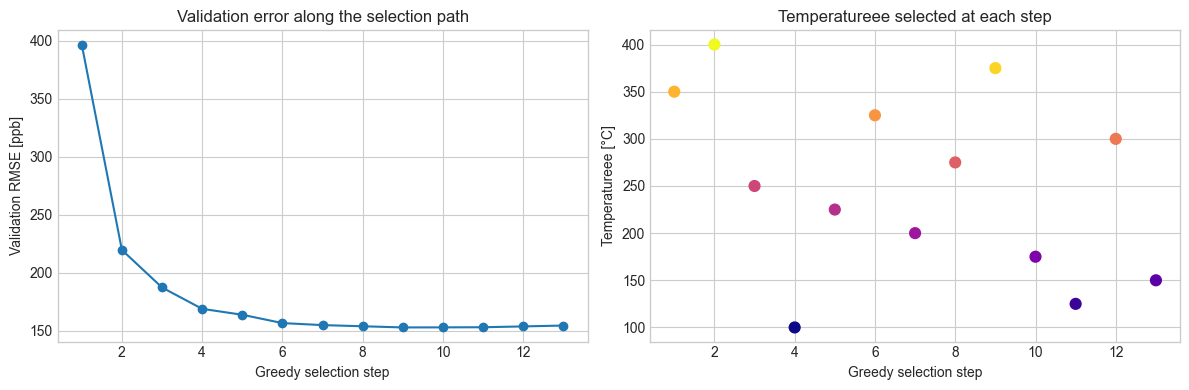

In [5]:
steps = np.arange(1, len(selected_points) + 1)
temperatures = [point.temperature_c for point in selected_points]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(steps, selection_history, marker="o")
axes[0].set(
    xlabel="Greedy selection step",
    ylabel="Validation RMSE [ppb]",
    title="Validation error along the selection path",
)
axes[1].scatter(steps, temperatures, c=temperatures, cmap="plasma", s=60)
axes[1].set(
    xlabel="Greedy selection step",
    ylabel="Temperatureee [°C]",
    title="Temperatureee selected at each step",
)
fig.tight_layout()

## 3. Compare models as the number of shared points grows


Intermediate results: what do added features contribute?
Points  Model                           Val-RMSE    Test-RMSE    Extra-RMSE
----------------------------------------------------------------------------
     1  Linear: stored values            393.032      382.013       782.963
     1  Linear: log1p(x)                 393.012      382.224       796.283
     1  Multi-point power law            396.623      407.317      1057.791
     2  Linear: stored values            237.712      239.648       456.809
     2  Linear: log1p(x)                 236.133      239.201       461.278
     2  Multi-point power law            219.759      249.359       476.849
     3  Linear: stored values            203.948      221.012       438.784
     3  Linear: log1p(x)                 201.903      220.114       442.077
     3  Multi-point power law            187.427      232.781       448.527
     5  Linear: stored values            178.387      200.831       432.217
     5  Linear: log1p(x)     

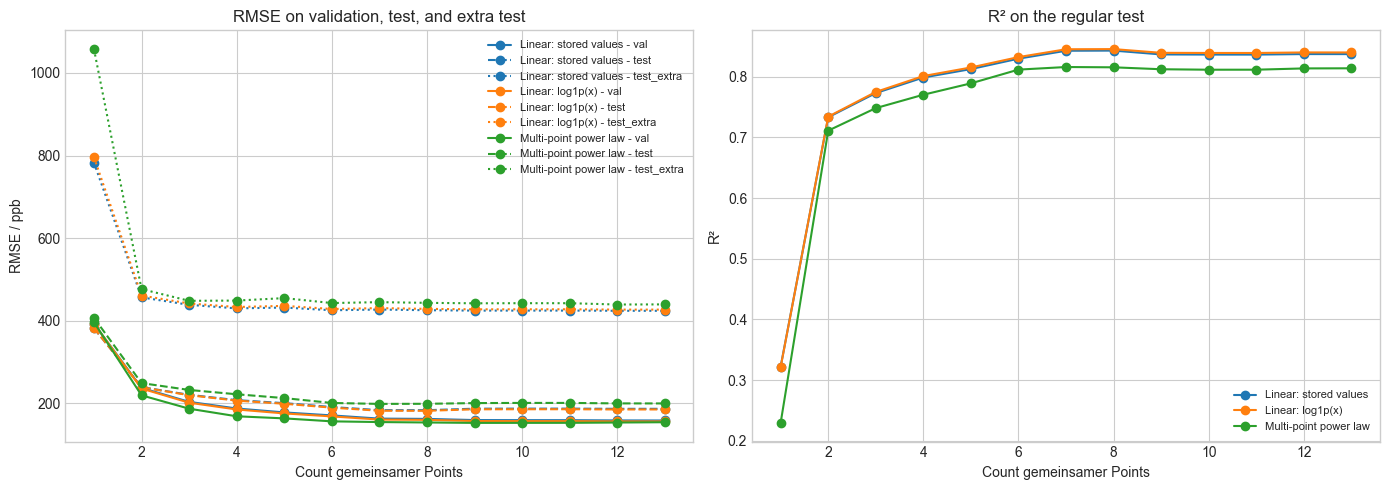

In [6]:
model_factories = (
    make_linear_raw, make_linear_log1p, make_power_law
)
count_results = []
for count in range(1, N_FEATURES + 1):
    indices = selected_indices[:count]
    X_train = matrix("train", indices)
    fitted = [
        factory(X_train, y_train) for factory in model_factories
    ]
    evaluation = {}
    for model in fitted:
        evaluation[model["name"]] = {}
        for split in SPLIT_NAMES:
            y = splits[split]["targets"][GAS].astype(float)
            pred = model["predict"](matrix(split, indices))
            evaluation[model["name"]][split] = metrics(y, pred)
    count_results.append({
        "count": count,
        "indices": indices,
        "models": fitted,
        "metrics": evaluation,
    })

# Show intermediate models, not only 1 and N features.
milestone_counts = sorted({
    count for count in (1, 2, 3, 5, 8, N_FEATURES)
    if count <= N_FEATURES
})
print("\nIntermediate results: what do added features contribute?")
print(
    f"{'Points':>6}  {'Model':<28}  "
    f"{'Val-RMSE':>10}  {'Test-RMSE':>11}  {'Extra-RMSE':>12}"
)
print("-" * 76)
for count in milestone_counts:
    result = count_results[count - 1]
    for model_name in result["metrics"]:
        model_metrics = result["metrics"][model_name]
        print(
            f"{count:6d}  {model_name:<28}  "
            f"{model_metrics['val']['RMSE']:10.3f}  "
            f"{model_metrics['test']['RMSE']:11.3f}  "
            f"{model_metrics['test_extra']['RMSE']:12.3f}"
        )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_colors = {
    "Linear: stored values": "tab:blue",
    "Linear: log1p(x)": "tab:orange",
    "Multi-point power law": "tab:green",
}
for model_name, color in model_colors.items():
    for split, linestyle in (
        ("val", "-"), ("test", "--"), ("test_extra", ":")
    ):
        values = [
            item["metrics"][model_name][split]["RMSE"]
            for item in count_results
        ]
        axes[0].plot(
            range(1, N_FEATURES + 1), values, marker="o",
            linestyle=linestyle, color=color,
            label=f"{model_name} - {split}"
        )
    r2_values = [
        item["metrics"][model_name]["test"]["R2"]
        for item in count_results
    ]
    axes[1].plot(
        range(1, N_FEATURES + 1), r2_values,
        marker="o", color=color, label=model_name
    )
axes[0].set(
    xlabel="Count gemeinsamer Points", ylabel="RMSE / ppb",
    title="RMSE on validation, test, and extra test"
)
axes[1].set(
    xlabel="Count gemeinsamer Points", ylabel="R²",
    title="R² on the regular test"
)
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()

Intermediate models make the trade-off visible. Two, three, or five points may perform
almost as well as all points. If validation error rises after a minimum, added features provide
no robust information; feature count is therefore also a hyperparameter.

## 4. Final models using all selected points

In [7]:
final = count_results[-1]
models = final["models"]
results = final["metrics"]
predictions = {}
for model in models:
    predictions[model["name"]] = {
        split: model["predict"](matrix(split, selected_indices))
        for split in SPLIT_NAMES
    }

print("Points used:")
for position, point in enumerate(selected_points, 1):
    print(
        f"{position}: {point.point_id} "
        f"(T={point.temperature_c} °C, {point.edge})"
    )
print()
print("Model                     Split             R2"
      "           MSE          RMSE           MAE")
for model in models:
    name = model["name"]
    for split in SPLIT_NAMES:
        m = results[name][split]
        print(
            f"{name:27s} {split:10s} {m['R2']:11.4f} "
            f"{m['MSE']:13.4f} {m['RMSE']:13.4f} "
            f"{m['MAE']:13.4f}"
        )
    print()

Points used:
1: t350_low_step10_end_i1319 (T=350 °C, end)
2: t400_high_step05_end_i0649 (T=400 °C, end)
3: t250_low_step06_end_i0839 (T=250 °C, end)
4: t100_low_step00_end_i0119 (T=100 °C, end)
5: t225_low_step05_end_i0719 (T=225 °C, end)
6: t325_low_step09_end_i1199 (T=325 °C, end)
7: t200_low_step04_end_i0599 (T=200 °C, end)
8: t275_low_step07_start_i0890 (T=275 °C, start)
9: t375_low_step11_end_i1439 (T=375 °C, end)
10: t175_low_step03_start_i0410 (T=175 °C, start)
11: t125_low_step01_start_i0170 (T=125 °C, start)
12: t300_low_step08_end_i1079 (T=300 °C, end)
13: t150_low_step02_start_i0290 (T=150 °C, start)

Model                     Split             R2           MSE          RMSE           MAE
Linear: stored values       train           0.8330    35032.2469      187.1690      143.9465
Linear: stored values       val             0.8780    25239.9953      158.8710      126.8539
Linear: stored values       test            0.8374    35018.5487      187.1324      146.5274
Linear: stor

## 5. Parameters of the multi-point power law

In [8]:
power_model = next(
    model for model in models
    if model["name"] == "Multi-point power law"
)
parameters = power_model["parameters"]
print(f"A = {parameters['A']:.8g}")
print("Point                                Scale s_j     Exponent n_j")
for point, scale, exponent in zip(
    selected_points, parameters["scales"], parameters["n"]
):
    print(
        f"{point.point_id:36s} "
        f"{scale:12.4f} {exponent:14.6f}"
    )

A = 1162.4388
Point                                Scale s_j     Exponent n_j
t350_low_step10_end_i1319              33120.0000     -39.674636
t400_high_step05_end_i0649             31573.5000      58.020631
t250_low_step06_end_i0839              40232.5000      15.793925
t100_low_step00_end_i0119              57493.0000     -49.017260
t225_low_step05_end_i0719              42521.5000      36.808094
t325_low_step09_end_i1199              34482.5000     -29.294387
t200_low_step04_end_i0599              45024.0000      38.992620
t275_low_step07_start_i0890            39043.0000       7.145665
t375_low_step11_end_i1439              32247.0000     -36.555279
t175_low_step03_start_i0410            46327.0000      -0.459405
t125_low_step01_start_i0170            48231.0000      -0.300258
t300_low_step08_end_i1079              36196.0000     -15.412840
t150_low_step02_start_i0290            47263.0000      -0.487594


## 6. Final metric comparison

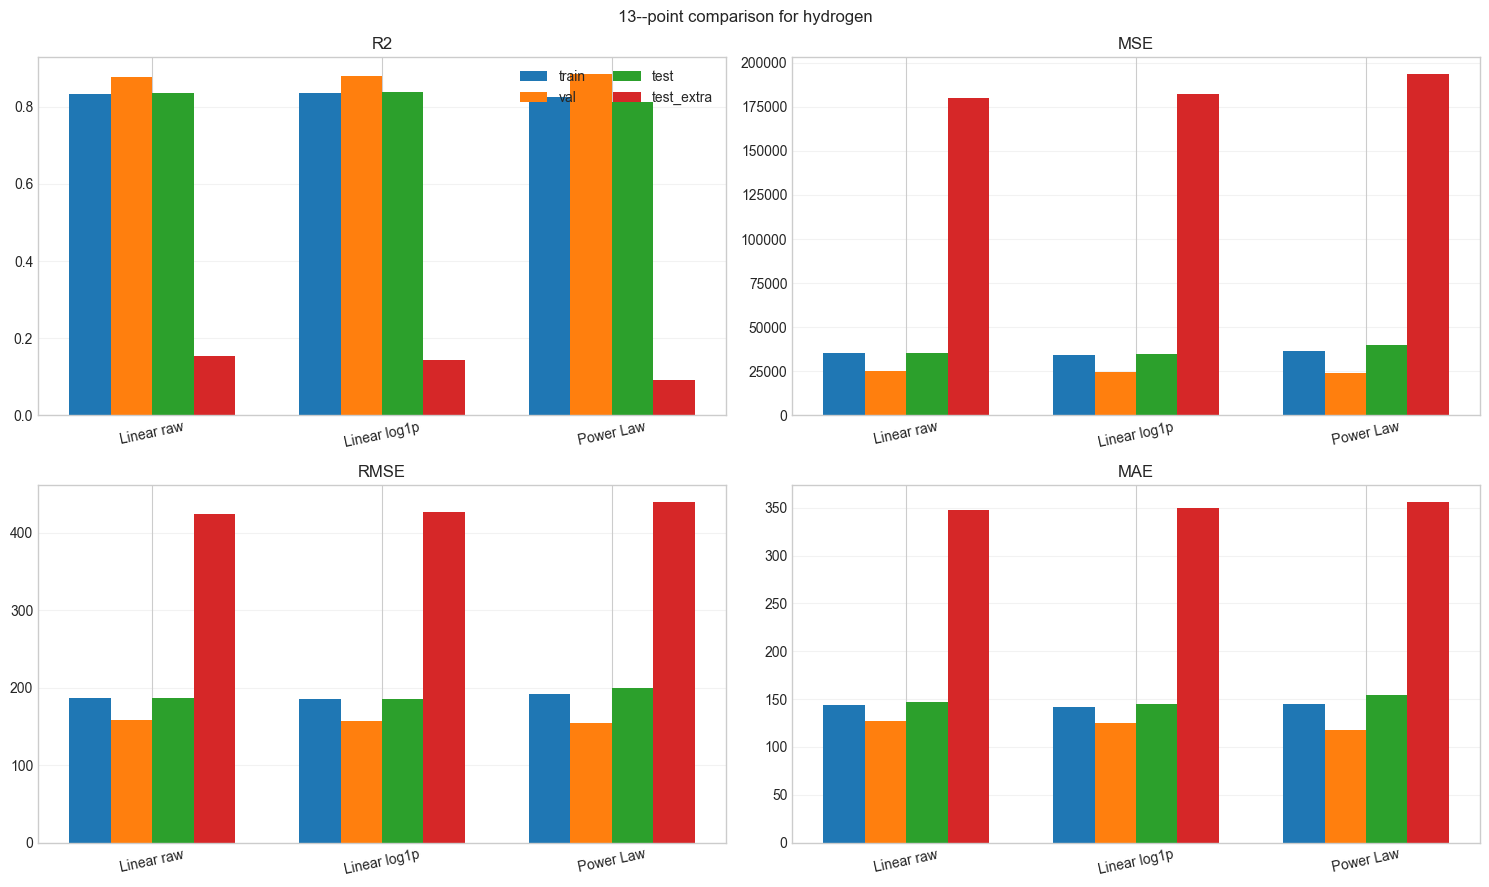

In [9]:
metric_names = ("R2", "MSE", "RMSE", "MAE")
split_colors = {
    "train": "tab:blue", "val": "tab:orange",
    "test": "tab:green", "test_extra": "tab:red",
}
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
positions = np.arange(len(models))
width = 0.18
for ax, metric_name in zip(axes.ravel(), metric_names):
    for offset, split in enumerate(SPLIT_NAMES):
        values = [
            results[model["name"]][split][metric_name]
            for model in models
        ]
        ax.bar(
            positions + (offset - 1.5) * width, values,
            width=width, label=split, color=split_colors[split]
        )
    ax.set_title(metric_name)
    ax.set_xticks(positions)
    ax.set_xticklabels(
        ["Linear raw", "Linear log1p", "Power Law"],
        rotation=12
    )
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].legend(ncol=2)
fig.suptitle(
    f"{N_FEATURES}--point comparison for {GAS}"
)
plt.tight_layout()

## 7. Parity plots for every model and split

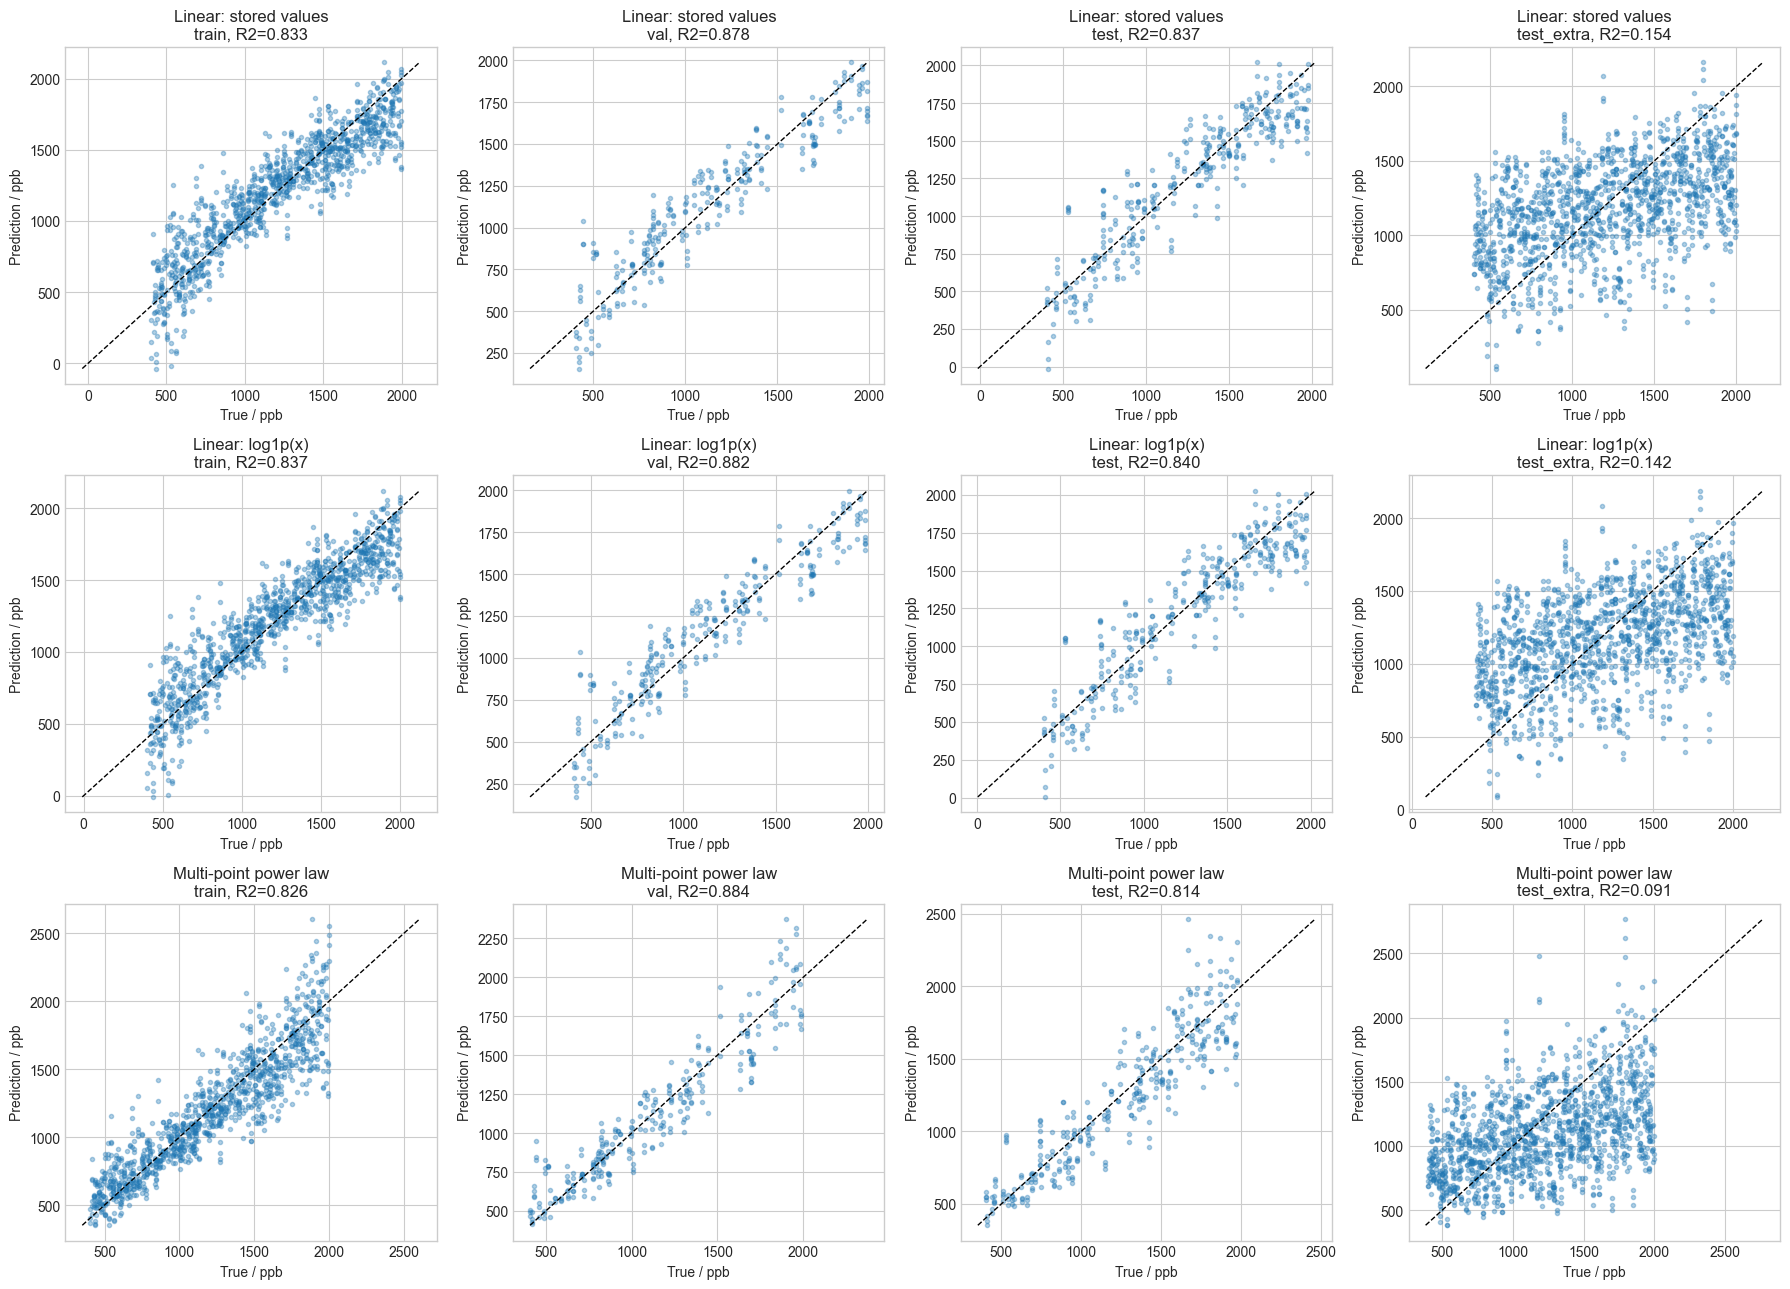

In [10]:
fig, axes = plt.subplots(
    len(models), len(SPLIT_NAMES), figsize=(18, 13)
)
for row, model in enumerate(models):
    name = model["name"]
    for column, split in enumerate(SPLIT_NAMES):
        ax = axes[row, column]
        y = splits[split]["targets"][GAS].astype(float)
        pred = predictions[name][split]
        ax.scatter(y, pred, s=9, alpha=0.35)
        low = min(float(y.min()), float(np.nanmin(pred)))
        high = max(float(y.max()), float(np.nanmax(pred)))
        ax.plot([low, high], [low, high], "k--", linewidth=1)
        ax.set_title(
            f"{name}\n{split}, "
            f"R2={results[name][split]['R2']:.3f}"
        )
        ax.set_xlabel("True / ppb")
        ax.set_ylabel("Prediction / ppb")
plt.tight_layout()

All models receive the same points, so differences come from model form rather than separate
feature selection. Selection favors the power law on validation; test values must not drive
further point choices.